# EDA: анамнезы и группы ограничений

Разведочный анализ перед обучением: распределение групп, дисбаланс, доминирующие коды, длины текстов, проверка утечек между сплитами.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_split, load_xy, normalize
from src.mapping import GROUPS, description_of, group_of, is_dropped

REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
rows = []
for split in ("train", "dev", "test"):
    for r in load_split(split):
        rows.append({
            "split": split,
            "code": r["code"],
            "group": group_of(r["code"]),
            "dropped": is_dropped(r["code"]),
            "text": r["symptoms"],
        })
df = pd.DataFrame(rows)
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].apply(lambda t: len(normalize(t).split()))
print("всего записей:", len(df))
print(df["split"].value_counts().to_dict())
df.head()

всего записей: 6360
{'train': 4690, 'dev': 848, 'test': 822}


,split,code,group,dropped,text,n_chars,n_words
0,train,M17,СУСТАВЫ,False,Жалобы на болит во всех суставах но более в кр...,184,30
1,train,M53,ПОЗВОНОЧНИК,False,На боли в правом плече с иррадиацией в локтево...,55,10
2,train,K29,ЖКТ/БРЮШНЫЕ,False,"боль в эпигастрии после погрешности в диете, в...",93,14
3,train,M54,ПОЗВОНОЧНИК,False,"боль в правом плечевом суставе, в правом плече...",220,34
4,train,E27,ЭНДОКРИН/МЕТАБОЛ,False,- приливы пота в только на улице - снижение ве...,138,25


## Распределение по группам и дисбаланс

DROP-коды (D50/H65/Z00) исключаются из обучения, поэтому смотрим на 8 рабочих групп.

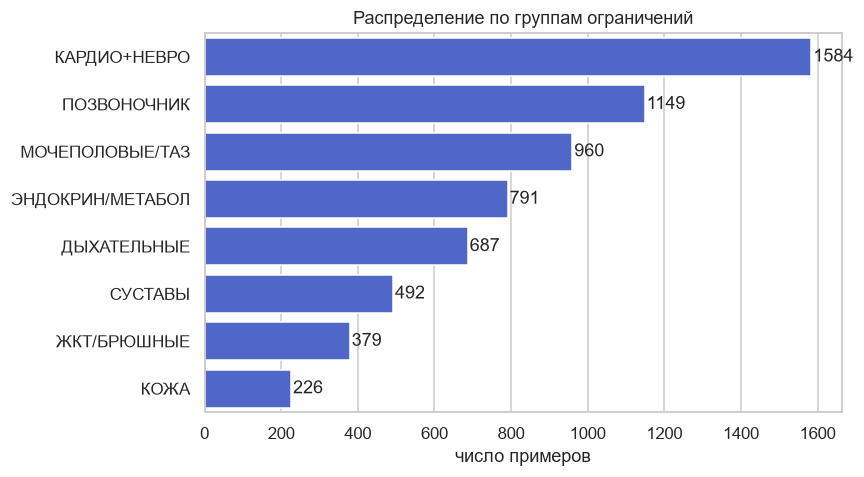

дисбаланс (max/min): 7.0x  (КАРДИО+НЕВРО 1584 vs КОЖА 226)
доля most-frequent class: 0.253


In [3]:
work = df[~df["dropped"]]
counts = work["group"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#3b5bdb")
ax.set_xlabel("число примеров")
ax.set_ylabel("")
ax.set_title("Распределение по группам ограничений")
for i, v in enumerate(counts.values):
    ax.text(v + 5, i, str(v), va="center")
fig.tight_layout()
fig.savefig(REPORTS / "group_distribution.png")
plt.show()

ratio = counts.max() / counts.min()
print(f"дисбаланс (max/min): {ratio:.1f}x  ({counts.idxmax()} {counts.max()} vs {counts.idxmin()} {counts.min()})")
print(f"доля most-frequent class: {counts.max() / counts.sum():.3f}")

In [4]:
pivot = (
    work.groupby(["group", "split"]).size().unstack(fill_value=0)
    .reindex(columns=["train", "dev", "test"])
    .loc[counts.index]
)
print("баланс групп по сплитам (доли):")
pivot.div(pivot.sum(axis=0), axis=1).round(3)

баланс групп по сплитам (доли):


split,train,dev,test
group,,,
КАРДИО+НЕВРО,0.244,0.288,0.264
ПОЗВОНОЧНИК,0.189,0.165,0.170
МОЧЕПОЛОВЫЕ/ТАЗ,0.158,0.134,0.147
ЭНДОКРИН/МЕТАБОЛ,0.126,0.125,0.131
ДЫХАТЕЛЬНЫЕ,0.108,0.114,0.113
СУСТАВЫ,0.081,0.068,0.075
ЖКТ/БРЮШНЫЕ,0.060,0.061,0.065
КОЖА,0.034,0.045,0.036


## Доминирующие коды внутри групп

Если один код перетягивает группу, модель рискует выучить его, а не группу в целом.

In [5]:
for g in counts.index:
    sub = work[work["group"] == g]["code"].value_counts()
    top = sub.index[0]
    share = sub.iloc[0] / sub.sum()
    print(f"{g:18s} топ-код {top} ({description_of(top)}) — {share:.0%} группы")

КАРДИО+НЕВРО       топ-код I11 (Гипертензивная болезнь сердца) — 23% группы
ПОЗВОНОЧНИК        топ-код M54 (Дорсалгия) — 64% группы
МОЧЕПОЛОВЫЕ/ТАЗ    топ-код N76 (Воспаление влагалища и вульвы) — 12% группы
ЭНДОКРИН/МЕТАБОЛ   топ-код E06 (Тиреоидит) — 28% группы
ДЫХАТЕЛЬНЫЕ        топ-код J06 (ОРВИ верхних дыхательных путей) — 24% группы
СУСТАВЫ            топ-код M13 (Другие артриты) — 24% группы
ЖКТ/БРЮШНЫЕ        топ-код K29 (Гастрит и дуоденит) — 28% группы
КОЖА               топ-код L30 (Другие дерматиты) — 24% группы


## Длины текстов жалоб

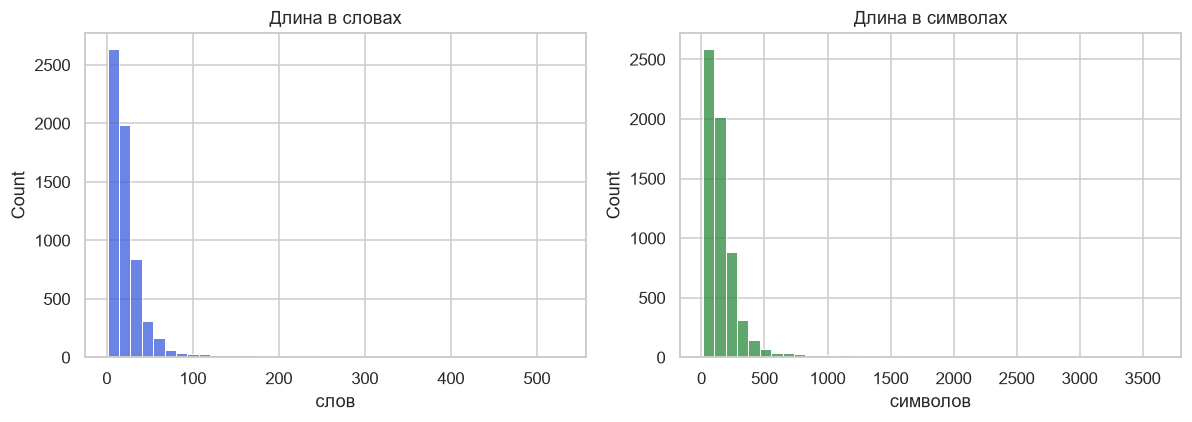

       n_words  n_chars
count   6268.0   6268.0
mean      26.0    177.8
std       35.7    238.8
min        1.0     10.0
25%       10.0     71.0
50%       17.0    119.0
75%       28.0    197.0
max      531.0   3627.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(work["n_words"], bins=40, ax=axes[0], color="#3b5bdb")
axes[0].set_title("Длина в словах")
axes[0].set_xlabel("слов")
sns.histplot(work["n_chars"], bins=40, ax=axes[1], color="#2b8a3e")
axes[1].set_title("Длина в символах")
axes[1].set_xlabel("символов")
fig.tight_layout()
fig.savefig(REPORTS / "text_lengths.png")
plt.show()

print(work[["n_words", "n_chars"]].describe().round(1))

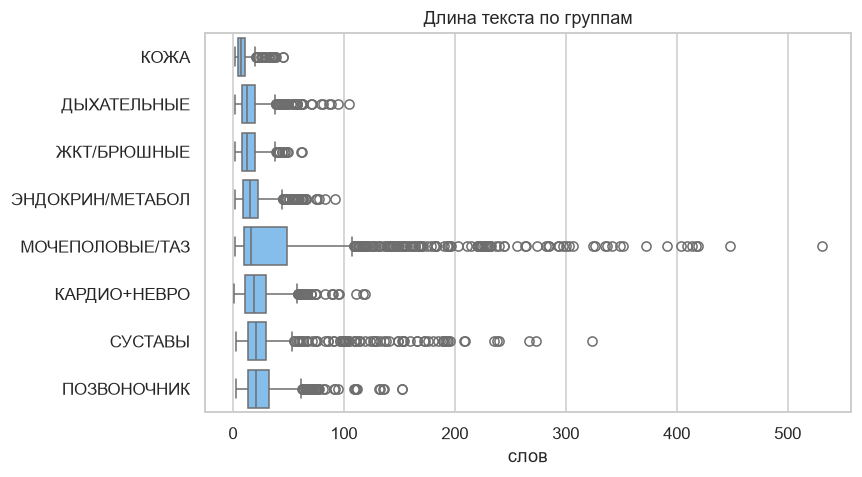

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = work.groupby("group")["n_words"].median().sort_values().index
sns.boxplot(data=work, x="n_words", y="group", order=order, ax=ax, color="#74c0fc")
ax.set_title("Длина текста по группам")
ax.set_xlabel("слов")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(REPORTS / "length_by_group.png")
plt.show()

## Аномалии длины и дубликаты

Проверяем выбросы по длине методом межквартильного размаха (IQR) и точные дубликаты.
Решение по чистке — осознанное: удаляем только то, что действительно шум, а не всё за усами.

In [8]:
# Аномалии длины (IQR) и точные дубликаты
nw = work["n_words"]
q1, q3 = nw.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"слов: median={nw.median():.0f}  Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}")
print(f"IQR-усы: [{max(lo, 0):.0f}, {hi:.0f}]")
print(f"длинные (> {hi:.0f} слов): {(nw > hi).sum()}   очень короткие (<= 2 слов): {(nw <= 2).sum()}")

print("\nсамые короткие жалобы:")
for _, r in work.nsmallest(6, "n_words").iterrows():
    print(f"  [{r.n_words}w] {r.group:16s} | {r.text[:55]!r}")

dups = work["text"].apply(normalize).duplicated().sum()
print(f"\nточных дублей (по нормализованному тексту): {dups}")

слов: median=17  Q1=10  Q3=28  IQR=18
IQR-усы: [0, 55]
длинные (> 55 слов): 457   очень короткие (<= 2 слов): 25

самые короткие жалобы:
  [1w] КАРДИО+НЕВРО     | 'головокружение'
  [2w] ЭНДОКРИН/МЕТАБОЛ | '- нестабильный'
  [2w] КАРДИО+НЕВРО     | 'головокружения периодические'
  [2w] КАРДИО+НЕВРО     | 'головокружение купировано.'
  [2w] КАРДИО+НЕВРО     | 'снижение зрения.'
  [2w] КОЖА             | 'Рецидивирующая крапивница.'

точных дублей (по нормализованному тексту): 1


## Чистка данных

Не все короткие жалобы бесполезны: «Иногда изжога», «на боль в пояснице» — валидные симптомы.
Удаляем только **административные записи без жалобы** («плановая консультация», «Визит повторный»,
«Общее самочувствие нормальное») — симптома в них нет, а код МКБ проставлен по визиту.

Правило — `is_uninformative` в `src/data.py`, применяется одинаково ко всем сплитам.
Плюс точный дубликат в train.

In [9]:
from src.data import is_uninformative

df["uninformative"] = df["text"].apply(is_uninformative)
df["norm"] = df["text"].apply(normalize)
work = df[~df["dropped"]]

for sp in ("train", "dev", "test"):
    sub = work[work["split"] == sp]
    n = sub["uninformative"].sum()
    print(f"{sp:6s} без жалобы: {n:3d} из {len(sub):5d} ({n / len(sub):.2%})")

print("\nудаляемые записи:")
for _, r in work[work["uninformative"]].sort_values(["split", "group"]).iterrows():
    print(f"  [{r.split:5s} | {r.group:16s}] {r.text!r}")

train = work[work["split"] == "train"]
dup = train["norm"].duplicated(keep="first")
print(f"\nточных дублей в train: {dup.sum()}")

removed = int(work["uninformative"].sum()) + int(dup.sum())
print(f"итого удалено: {removed} из {len(work)} ({removed / len(work):.2%})")

train  без жалобы:  18 из  4627 (0.39%)
dev    без жалобы:   2 из   837 (0.24%)
test   без жалобы:   2 из   804 (0.25%)

удаляемые записи:
  [dev   | КАРДИО+НЕВРО    ] 'не предъявляет.'
  [dev   | КАРДИО+НЕВРО    ] 'Состояние улучшилось'
  [test  | ДЫХАТЕЛЬНЫЕ     ] 'Состояние стабильное , жалоб нет'
  [test  | ЭНДОКРИН/МЕТАБОЛ] 'Повторный прием *ДАТА*: общее самочувствие нормальное.'
  [train | ДЫХАТЕЛЬНЫЕ     ] 'Состояние без динамики'
  [train | ДЫХАТЕЛЬНЫЕ     ] 'Состояние улучшилось, жалоб нет.'
  [train | КАРДИО+НЕВРО    ] 'на момент осмотра нет'
  [train | КАРДИО+НЕВРО    ] 'с жалобами ознакомлена.'
  [train | КАРДИО+НЕВРО    ] 'плановая консультация'
  [train | КАРДИО+НЕВРО    ] 'На момент осмотра жалоб нет.'
  [train | КАРДИО+НЕВРО    ] 'Жалоб нет на момент осмотра.'
  [train | МОЧЕПОЛОВЫЕ/ТАЗ ] 'активно не предъявляет .'
  [train | МОЧЕПОЛОВЫЕ/ТАЗ ] 'Прежние. Повторная консультация.'
  [train | МОЧЕПОЛОВЫЕ/ТАЗ ] 'Визит повторный'
  [train | МОЧЕПОЛОВЫЕ/ТАЗ ] 'Повторный осмотр

In [10]:
# Длинные жалобы — смотрим глазами: не склейка ли это нескольких приёмов и не мусор ли.
LONGEST = 5
print(f"{LONGEST} самых длинных жалоб (проверить вручную):\n")
for _, r in work.nlargest(LONGEST, "n_words").iterrows():
    tail = "..." if len(r.text) > 400 else ""
    print(f"[{r.split} | {r.group} | {r.n_words} слов]")
    print(f"  {r.text[:400]}{tail}\n")

5 самых длинных жалоб (проверить вручную):

[train | МОЧЕПОЛОВЫЕ/ТАЗ | 531 слов]
  В *ДАТА*лапаротомия, субтотальная гистерэктомия без придатков. Жалобы на нарушение стула при нарушении диеты (склонность в жидкому стулу, к метеоризму). При попытке отмены Фемостон 1/5 (отменил гинеколог в *ДАТА* с учётом эпизода ОНМК в *ДАТА*) - возврат частых приливов. Самостоятельно в *ДАТА* вернулась к приёму Фемостона 1/5 - чувствует себя хорошо. С середины *ДАТА* принимает Фемостон Конти - ч...

[train | МОЧЕПОЛОВЫЕ/ТАЗ | 448 слов]
  Жалоб нет. Цикл 28-29 Не принимает Визанну с *ДАТА* , болей нет. После отмены Визанны цикл 24-29 дней, менструации 4-5 умеренные, умеренно болезненные в первые 2 дня. За последние 4 месяца (с *ДАТА*по *ДАТА*) вновь появились мелкие эндометриоидные кисты яичников. С *ДАТА* по *ДАТА* (1 год) принимала Визанну по поводу мелких эндометриоидных кист яичников, чувствует себя хорошо, прошли тазовые боли....

[train | МОЧЕПОЛОВЫЕ/ТАЗ | 419 слов]
  Последний год проживала в *СТ

## Проверка утечек между сплитами

Один и тот же текст не должен попадать в разные сплиты — иначе оценка завышена.

In [11]:
norm = df["text"].apply(normalize)
df_norm = df.assign(norm=norm)

split_sets = {s: set(df_norm[df_norm["split"] == s]["norm"]) for s in ("train", "dev", "test")}
for a, b in (("train", "dev"), ("train", "test"), ("dev", "test")):
    overlap = split_sets[a] & split_sets[b]
    print(f"{a} ∩ {b}: {len(overlap)} пересечений")

dup_in_train = df_norm[df_norm["split"] == "train"]["norm"].duplicated().sum()
print(f"дубликаты внутри train: {dup_in_train}")

train ∩ dev: 0 пересечений
train ∩ test: 0 пересечений
dev ∩ test: 0 пересечений
дубликаты внутри train: 1


## Выводы

- Классы несбалансированы → главная метрика **macro-F1**, baseline LogReg с `class_weight=balanced`.
- Внутри некоторых групп доминирует один код — учитываем при анализе ошибок.
- Тексты короткие → tf-idf и субсловные модели (fastText) уместны.
- Утечек между сплитами нет → оценка честная.
- Аномалий-выбросов нет: длинные тексты — валидные подробные анамнезы (трансформер обрезает по `max_length`), очень коротких (≤2 слов) лишь ~0.4%, точный дубликат 1 → данные оставляем без агрессивной чистки (решение обосновано анализом, а не «на глаз»).